# 03 — EDA & Visualization
Eksplorasi distribusi kelas, analisis spasial Bounding Box (BBox), dan insight kualitas dataset.

## Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Arahkan root path ke parent folder agar modul lokal terbaca
sys.path.insert(0, str(Path.cwd().parent))

from config.paths import OUTPUT_DIR, FIGURES_DIR, PLOT_CONFIG
from src.eda_utils import EDAPlotter

# Konfigurasi File Input (Memanggil file CSV yang sudah disucikan di tahap 02)
CLEAN_CSV = OUTPUT_DIR / "cleaned_human_fall.csv"

# Setel tema global visualisasi agar elegan dan selaras (Dark Mode)
plt.style.use(PLOT_CONFIG['style'])

print("[INFO] Lingkungan EDA dan Visualisasi siap mengudara!")

[INFO] Lingkungan EDA dan Visualisasi siap mengudara!


## 1. Load Clean Data

In [2]:
print("=== TAHAP 1: MEMUAT DATA BERSIH ===")

if not CLEAN_CSV.exists():
    raise FileNotFoundError(f"[ERROR] File {CLEAN_CSV} tidak ditemukan. Jalankan notebook 02 terlebih dahulu.")

df = pd.read_csv(CLEAN_CSV)
print(f"[INFO] Data berhasil dimuat. Bentuk (Shape): {df.shape}")

# Tampilkan informasi tipe data dan memori
df.info()

=== TAHAP 1: MEMUAT DATA BERSIH ===
[INFO] Data berhasil dimuat. Bentuk (Shape): (8034, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dataset        8034 non-null   object 
 1   split          8034 non-null   object 
 2   image_id       8034 non-null   object 
 3   image_path     8034 non-null   object 
 4   label_path     8034 non-null   object 
 5   img_exists     8034 non-null   bool   
 6   img_width      8034 non-null   int64  
 7   img_height     8034 non-null   int64  
 8   line_no        8034 non-null   int64  
 9   class_id       8034 non-null   int64  
 10  class_name     8034 non-null   object 
 11  bbox_x_center  8034 non-null   float64
 12  bbox_y_center  8034 non-null   float64
 13  bbox_width     8034 non-null   float64
 14  bbox_height    8034 non-null   float64
 15  format         8034 non-null   object 
 16  bbox

## 2. Summary Stats

In [3]:
print("\n=== TAHAP 2: STATISTIK DESKRIPTIF BBOX ===")

# Inisialisasi mesin plotter OOP milikmu
plotter = EDAPlotter(df)

# Menampilkan metrik rata-rata, median, dan standar deviasi dari BBox
plotter.summary_stats()


=== TAHAP 2: STATISTIK DESKRIPTIF BBOX ===
📊 [STATISTIK DESKRIPTIF DATASET]
 -> Total Baris   : 8,034
 -> Gambar Unik   : 7,822
 -> Rata-rata Lebar BBox  : 272.9 px
 -> Rata-rata Tinggi BBox : 281.8 px

Distribusi Kelas:
class_name
Fall-Detected    5916
Person           1203
fall detected     564
Fall-person       241
falling            80
fall               27
sitting             2
walking             1


## 3. Distribusi Kelas


=== TAHAP 3: DISTRIBUSI KELAS ===
 -> Grafik tersimpan di: 03a_class_distribution_clean.png


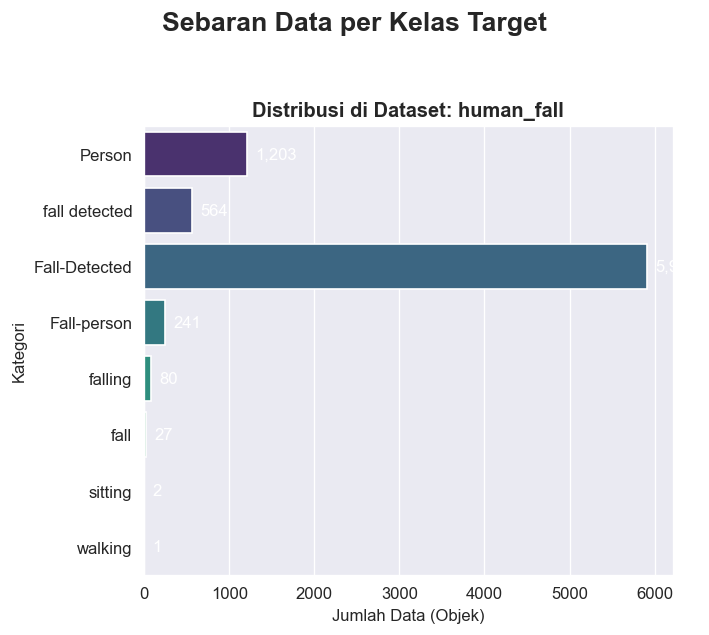

In [4]:
print("\n=== TAHAP 3: DISTRIBUSI KELAS ===")

fig_class = plotter.plot_class_distribution()

# Simpan figur secara otomatis ke folder laporan
path_fig_class = FIGURES_DIR / "03a_class_distribution_clean.png"
fig_class.savefig(path_fig_class, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
print(f" -> Grafik tersimpan di: {path_fig_class.name}")

## 4. Distribusi Ukuran BBox


=== TAHAP 4: DISTRIBUSI UKURAN BOUNDING BOX ===
 -> Grafik tersimpan di: 03b_bbox_size_distribution.png


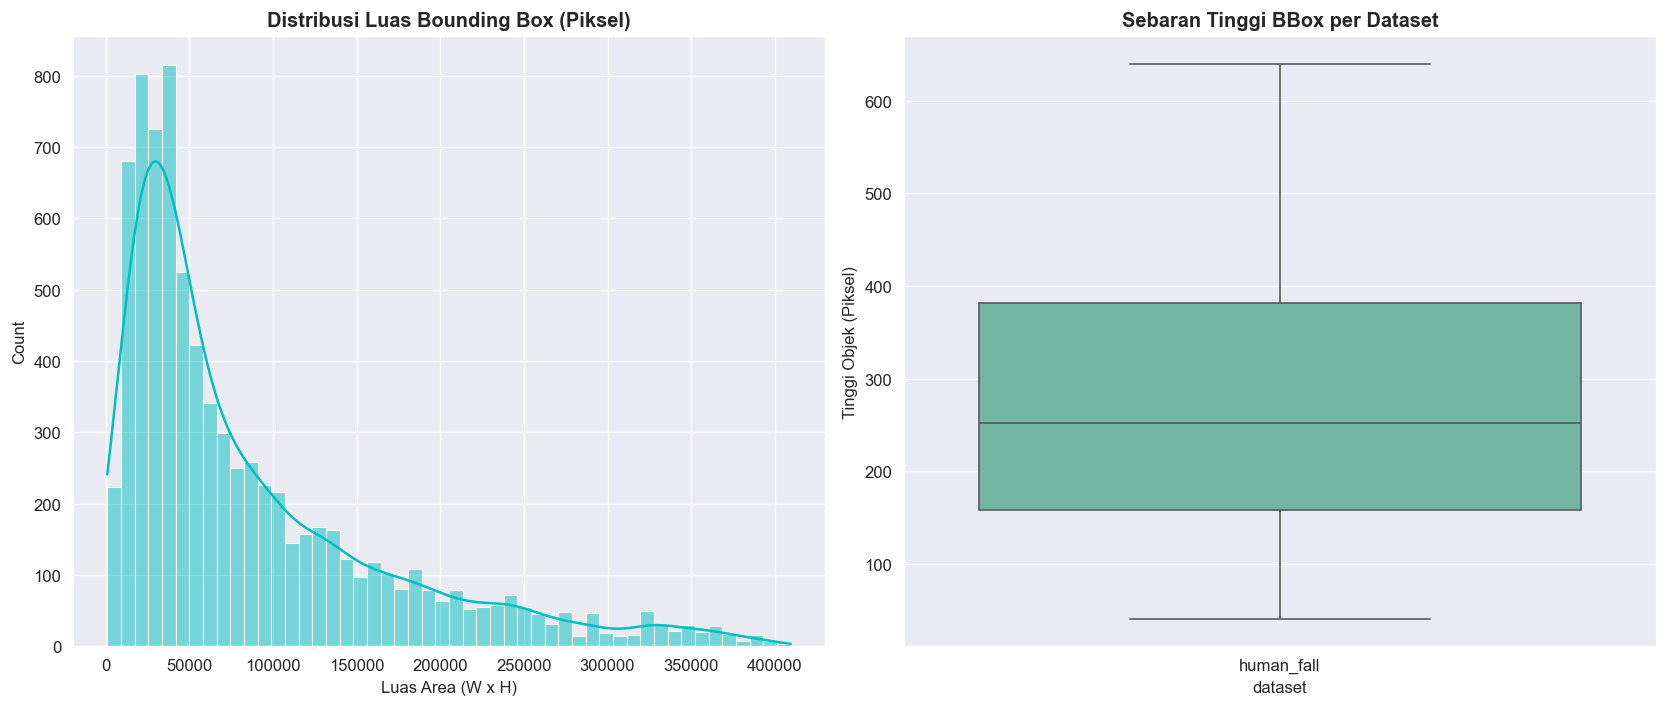

In [5]:
print("\n=== TAHAP 4: DISTRIBUSI UKURAN BOUNDING BOX ===")
# Sangat krusial untuk mengetahui apakah objek jatuh difoto dari jauh (kecil) atau dekat (besar)

fig_size = plotter.plot_bbox_size_distribution()

path_fig_size = FIGURES_DIR / "03b_bbox_size_distribution.png"
fig_size.savefig(path_fig_size, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
print(f" -> Grafik tersimpan di: {path_fig_size.name}")

## 5. Heatmap Posisi BBox


=== TAHAP 5: HEATMAP SPASIAL POSISI BBOX ===
 -> Grafik tersimpan di: 03c_bbox_spatial_heatmap.png


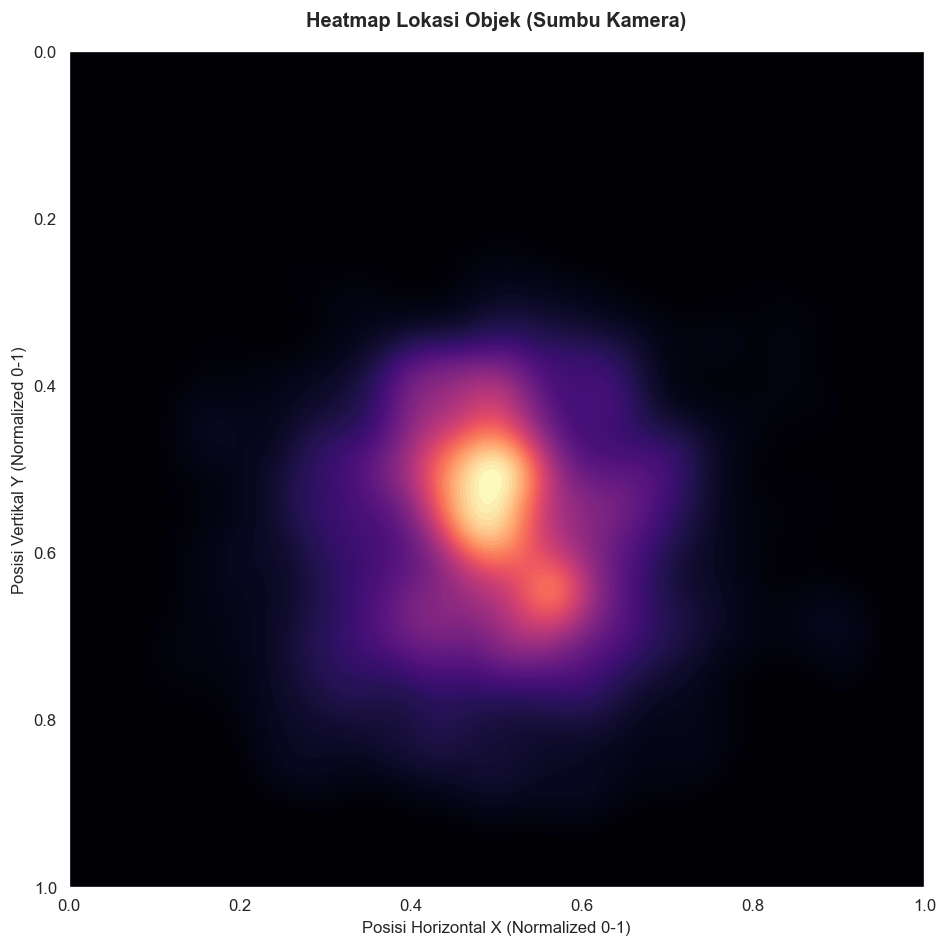

In [6]:
print("\n=== TAHAP 5: HEATMAP SPASIAL POSISI BBOX ===")
# Membantu melihat bias kamera. Apakah kejadian jatuh selalu ada di tengah layar?

fig_heat = plotter.plot_bbox_heatmap()

path_fig_heat = FIGURES_DIR / "03c_bbox_spatial_heatmap.png"
fig_heat.savefig(path_fig_heat, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
print(f" -> Grafik tersimpan di: {path_fig_heat.name}")

## 6. Anotasi per Gambar


=== TAHAP 6: JUMLAH ANOTASI (OBJEK) PER GAMBAR ===
 -> Grafik tersimpan di: 03d_annotations_per_image.png

[SUKSES] Seluruh visualisasi EDA telah diekspor. Dasbor Streamlit siap menyerap data ini!


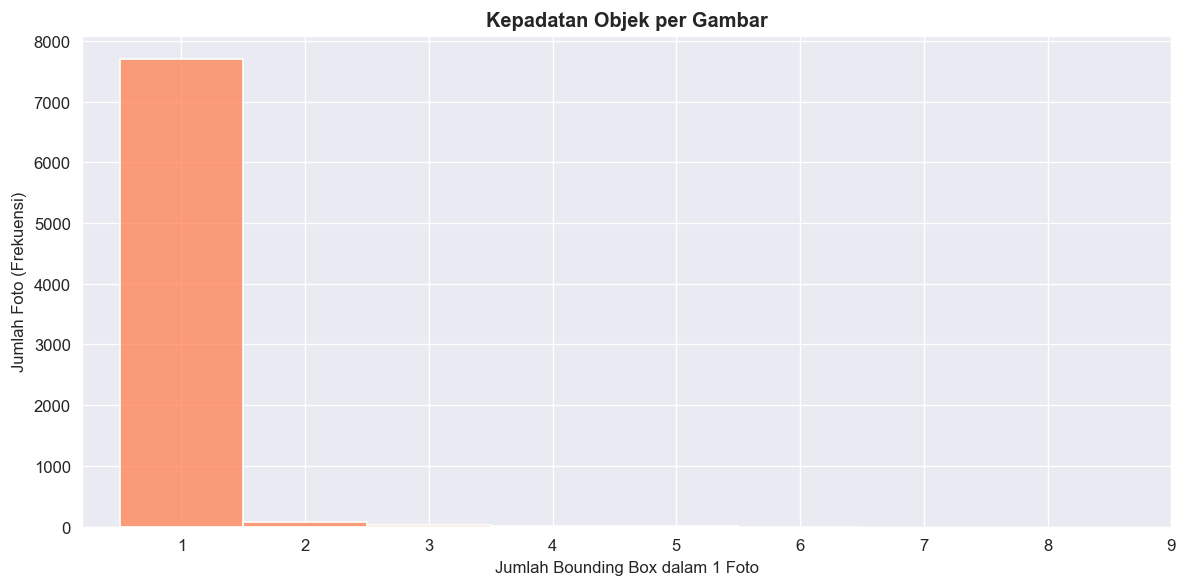

In [7]:
print("\n=== TAHAP 6: JUMLAH ANOTASI (OBJEK) PER GAMBAR ===")
# Mengecek keramaian gambar (apakah 1 gambar hanya ada 1 orang jatuh, atau ada orang lain yang berdiri?)

fig_anno = plotter.plot_annotations_per_image()

path_fig_anno = FIGURES_DIR / "03d_annotations_per_image.png"
fig_anno.savefig(path_fig_anno, dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
print(f" -> Grafik tersimpan di: {path_fig_anno.name}")
print("\n[SUKSES] Seluruh visualisasi EDA telah diekspor. Dasbor Streamlit siap menyerap data ini!")